# Ranking titles by Arabic-language interest

**Purpose**: exploratory, requested directly (2026-09-22). `viewership_snapshots.language` carries a real, non-null, self-declared broadcast language per channel -- `'ar'` (Arabic) is present as its own single tag, not a composite region requiring the multi-language mapping that caused the earlier Europe-coverage artifact (`region_coverage_artifact_test.ipynb`). This ranks all 23 tracked titles by Arabic-language creator presence.

**What this measures, stated precisely**: the *creator's own self-declared broadcast language*, not confirmed audience/viewer demographics -- same caveat as every other language-based finding this session (Twitch's own field, not this project's inference). "Interest" here means "how much of this title's Twitch creator activity is conducted in Arabic," a real and directly measurable proxy, not a claim about who's watching.

**Sample-size discipline, applied before any ranking is trusted**: `wider_game_fandoms`'s prior work found Mobile Legends: Bang Bang's apparent "89% Russian" audience read was a pure sample-size artifact, not a real finding (see `project_niche_membership_notebook` memory) -- several titles here have single-digit or zero Arabic-tagged channels, which would repeat that exact mistake if not filtered out explicitly.

In [1]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

from etl.db import get_connection

with open(REPO_ROOT / "config" / "titles.yaml") as f:
    titles_config = yaml.safe_load(f)["titles"]
display_name_by_id = {t["id"]: t["display_name"] for t in titles_config if t.get("is_active")}

In [2]:
# Majority self-declared language per (title, channel) -- same
# established pattern as region_language_confound.ipynb: a channel's
# language can vary across snapshots (different broadcasts, different
# self-tagging), so its MAJORITY tag across all its snapshots for this
# title is the more stable per-channel signal than any single snapshot.
conn = get_connection()
lang = pd.DataFrame(conn.execute(
    "SELECT title_id, channel_id, language, COUNT(*) n FROM viewership_snapshots "
    "WHERE is_official_broadcast = 0 GROUP BY title_id, channel_id, language"
).fetchall(), columns=["title_id", "channel_id", "language", "n"])
viewer_mass = pd.DataFrame(conn.execute(
    "SELECT title_id, channel_id, SUM(viewer_count) total_viewer_mass FROM viewership_snapshots "
    "WHERE is_official_broadcast = 0 GROUP BY title_id, channel_id"
).fetchall(), columns=["title_id", "channel_id", "total_viewer_mass"])
conn.close()

n_null_lang = lang["language"].isna().sum()
print(f"null language rows: {n_null_lang} of {len(lang)}")
top_lang = lang.sort_values("n", ascending=False).drop_duplicates(subset=["title_id", "channel_id"])
top_lang = top_lang.merge(viewer_mass, on=["title_id", "channel_id"], how="left")
print(f"{len(top_lang):,} (title, channel) pairs with a majority language")

null language rows: 0 of 259961


259,524 (title, channel) pairs with a majority language


In [3]:
# Two versions of "interest": share of a title's CHANNELS that are
# Arabic-language (a creator-population measure) and share of a title's
# total VIEWER MASS carried by Arabic-language channels (an audience-
# weighted measure) -- these can diverge, and the divergence itself is
# informative (see Read).
by_title = top_lang.groupby("title_id").agg(n_channels=("channel_id", "nunique"))
total_mass_by_title = top_lang.groupby("title_id")["total_viewer_mass"].sum().rename("total_viewer_mass")

ar = top_lang[top_lang["language"] == "ar"].groupby("title_id").agg(
    n_ar_channels=("channel_id", "nunique"), ar_viewer_mass=("total_viewer_mass", "sum")
)

result = by_title.join(ar, how="left").fillna(0).join(total_mass_by_title)
result["pct_channels_ar"] = (result["n_ar_channels"] / result["n_channels"] * 100).round(2)
result["pct_viewer_mass_ar"] = (result["ar_viewer_mass"] / result["total_viewer_mass"] * 100).round(2)
result["title"] = result.index.map(display_name_by_id)
result = result.sort_values("pct_channels_ar", ascending=False)
result[["title", "n_channels", "n_ar_channels", "pct_channels_ar", "pct_viewer_mass_ar"]]

,title,n_channels,n_ar_channels,pct_channels_ar,pct_viewer_mass_ar
title_id,,,,,
pubg_mobile,PUBG Mobile,755,48.0,6.36,15.48
overwatch,Overwatch,27714,789.0,2.85,3.58
valorant,VALORANT,47307,983.0,2.08,1.39
rocket_league,Rocket League,11766,240.0,2.04,5.59
tekken,Tekken 8,2423,24.0,0.99,0.36
hearthstone,Hearthstone,1464,11.0,0.75,0.88
apex_legends,Apex Legends,21997,144.0,0.65,0.30
free_fire,Free Fire,306,2.0,0.65,0.03
teamfight_tactics,Teamfight Tactics,5047,32.0,0.63,0.16


### Applying the minimum-sample floor before ranking

Several titles have single-digit or zero Arabic-tagged channels -- exactly the Mobile-Legends-89%-Russian situation, where a tiny numerator produces a headline-looking percentage that's really just noise. **Floor: 10 Arabic-tagged channels minimum** to appear in the ranking below (arbitrary but conservative -- lower than this and a single outlier channel can swing the percentage substantially).

In [4]:
MIN_AR_CHANNELS = 10
excluded = result[result["n_ar_channels"] < MIN_AR_CHANNELS]
ranked = result[result["n_ar_channels"] >= MIN_AR_CHANNELS].copy()

print(f"{len(ranked)} of 23 titles have {MIN_AR_CHANNELS}+ Arabic-tagged channels and are ranked below")
print(f"\nExcluded for too few Arabic-tagged channels (shown, not ranked):")
print(excluded[["title", "n_channels", "n_ar_channels"]].to_string(index=False))

13 of 23 titles have 10+ Arabic-tagged channels and are ranked below

Excluded for too few Arabic-tagged channels (shown, not ranked):
                       title  n_channels  n_ar_channels
                   Free Fire         306            2.0
   Mobile Legends: Bang Bang        1158            4.0
League of Legends: Wild Rift         608            2.0
            Street Fighter 6        3546            6.0
           Age of Empires II         661            1.0
                 Brawl Stars        1415            1.0
                      Dota 2       10592            4.0
        Guilty Gear -Strive-         524            0.0
             Mortal Kombat 1         429            0.0
                StarCraft II         568            0.0


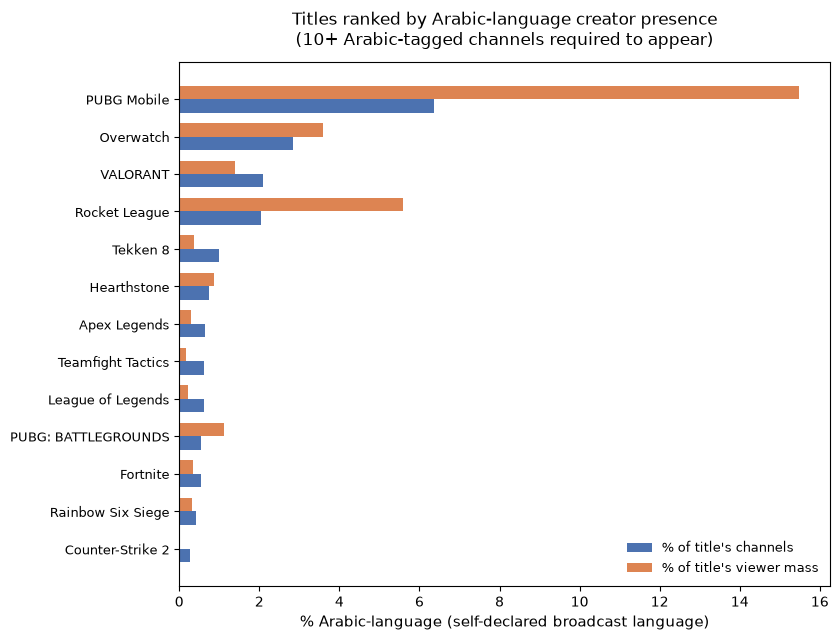

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 6.5))
y_pos = np.arange(len(ranked))
bar_h = 0.36

ax.barh(y_pos + bar_h/2, ranked["pct_channels_ar"], height=bar_h, color="#4C72B0", label="% of title's channels")
ax.barh(y_pos - bar_h/2, ranked["pct_viewer_mass_ar"], height=bar_h, color="#DD8452", label="% of title's viewer mass")

ax.set_yticks(y_pos)
ax.set_yticklabels(ranked["title"], fontsize=9.5)
ax.invert_yaxis()
ax.set_xlabel("% Arabic-language (self-declared broadcast language)", fontsize=10.5)
ax.set_title(f"Titles ranked by Arabic-language creator presence\n({MIN_AR_CHANNELS}+ Arabic-tagged channels required to appear)", fontsize=12, pad=12)
ax.legend(loc="lower right", fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig(Path.cwd() / "_arabic_interest_fig1_ranking.png", dpi=200, bbox_inches="tight")
plt.show()

### Read -- PUBG Mobile is a clear, real standout; most of the rest is a thin, low-magnitude signal

**PUBG Mobile is the one title with an unambiguous Arabic-language presence, on both measures.** 6.36% of its channels are Arabic-tagged, and those channels carry 15.48% of its total viewer mass -- Arabic-language PUBG Mobile creators run more than twice their population share in audience terms, a real, sizeable, and directionally consistent finding (48 Arabic-tagged channels, well clear of the sample floor). This lines up with PUBG Mobile's well-documented real-world popularity in the MENA region -- a case where the data and outside knowledge agree, worth noting since that isn't guaranteed with a self-declared, creator-side proxy like this one.

**Everything else ranked is a much thinner signal, under 3% of channels for every other title.** Overwatch (2.85%) and VALORANT (2.08%) are the next-highest on channel share; Rocket League (2.04% of channels but 5.59% of viewer mass -- a similar, smaller version of PUBG Mobile's pattern) is the next-most-interesting on the audience-weighted measure. Below that, the ranking is mostly noise-adjacent -- real, floor-cleared signal, but small enough (well under 1% for most titles) that ordering position within the bottom half of this ranking shouldn't be read as meaningful.

**10 of 23 titles were excluded outright for too few Arabic-tagged channels** (0-6 each) -- Free Fire, Mobile Legends: Bang Bang, Wild Rift, Street Fighter 6, Age of Empires II, Brawl Stars, Dota 2, Guilty Gear, Mortal Kombat, StarCraft II. Worth flagging directly: several of these (Free Fire, MLBB, Wild Rift) are titles with real, substantial audiences in Arabic-speaking markets by outside knowledge -- their absence here most likely reflects this project's own small total channel counts for these titles (Free Fire n=306, Wild Rift n=608, MLBB n=1,158, all among the smallest-tracked populations) combined with the short ~3-week collector window, not an actual absence of Arabic-language interest. **Read this ranking as "measurable within the current sample," not "the true picture" for the excluded titles** -- the floor is doing its job (preventing a false headline number) but it's also hiding a real signal this dataset just isn't big enough yet to detect for several titles.

**Standing caveat, restated**: this is creator-side self-declared broadcast language, not confirmed viewer/audience demographics. A reasonable, directly measurable proxy -- not proof of who's actually watching.